[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/geo-di-lab/emerge-geoai/blob/main/docs/ch4/lesson2.ipynb)

# Classification

Classifying water source photos from GLOBE participatory science through transfer learning with ResNet-50.

In [5]:
# Install required packages

!pip install -q tensorflow pillow scikit-learn matplotlib transformers huggingface_hub
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from pathlib import Path

Below, we'll load the images of mosquito habitats (water sources) from NASA GLOBE. For more information, check out [Introduction to GLOBE Data](https://geo-di-lab.github.io/emerge-lessons/docs/ch1/lesson6).

In [6]:
# Load GLOBE Mosquito Habitat Data

# Get the photo links from the GLOBE observations
mosquito = gpd.read_file('https://github.com/geo-di-lab/emerge-lessons/raw/refs/heads/main/docs/data/globe_mosquito.zip')
data = mosquito.dropna(subset=['WaterSourcePhotoUrls'])[['WaterSourcePhotoUrls', 'WaterSourceType']].copy()
data['WaterSourcePhotoUrls'] = data['WaterSourcePhotoUrls'].str.split(';') # Sometimes multiple URLs are included; split them into multiple rows
data = data.explode('WaterSourcePhotoUrls').reset_index(drop=True)
data['WaterSourcePhotoUrls'] = data['WaterSourcePhotoUrls'].str.strip()

# Count photos per water source classification
class_counts = data['WaterSourceType'].value_counts()
print(f"Total observations with photos: {len(data)}")
print(f"\nWater source types:\n{class_counts}")

Total observations with photos: 48381

Water source types:
WaterSourceType
container: artificial                                 37830
still: lake/pond/swamp                                 7142
container: natural                                     1820
flowing: still water found next to river or stream     1589
Name: count, dtype: int64


Next, we'll sample 200 total water source images (50 from each type) to fine-tune the classification model.

In [7]:
# Determine samples per class (200 total, distributed equally)
n_classes = len(class_counts)
samples_per_class = 200 // n_classes
print(f"\nSampling {samples_per_class} photos per class ({n_classes} classes)")

# Stratified sampling: equal number from each class
sample_data = data.groupby('WaterSourceType', group_keys=False).apply(
    lambda x: x.sample(n=min(samples_per_class, len(x)), random_state=42)
).reset_index(drop=True)

print(f"\nSampled {len(sample_data)} observations")
print(f"Balanced class distribution:\n{sample_data['WaterSourceType'].value_counts()}")

# ## Download and Process Images
# Images will be loaded, resized to 224x224 (ResNet-50 standard), and normalized

def download_image(url, target_size=(224, 224)):
    """Download and preprocess an image from URL"""
    try:
        response = requests.get(url, timeout=10)
        img = Image.open(BytesIO(response.content)).convert('RGB')
        img = img.resize(target_size)
        return np.array(img) / 255.0  # Normalize to [0,1]
    except:
        return None

print("Downloading images (this may take a few minutes)...")
images = []
labels = []

for idx, row in sample_data.iterrows():
    img = download_image(row['WaterSourcePhotoUrls'])
    if img is not None:
        images.append(img)
        labels.append(row['WaterSourceType'])
    if (idx + 1) % 50 == 0:
        print(f"Processed {idx + 1}/{len(sample_data)} images")

print(f"\nSuccessfully loaded {len(images)} images")


Sampling 50 photos per class (4 classes)

Sampled 200 observations
Balanced class distribution:
WaterSourceType
container: artificial                                 50
container: natural                                    50
flowing: still water found next to river or stream    50
still: lake/pond/swamp                                50
Name: count, dtype: int64
Processed 50/200 images
Processed 100/200 images
Processed 150/200 images
Processed 200/200 images

Successfully loaded 190 images


Here, we format the images and labels for training the model, and divide the data so that 80% will be used for training and 20% for testing.


Number of classes: 4
Classes: ['container: artificial' 'container: natural'
 'flowing: still water found next to river or stream'
 'still: lake/pond/swamp']
Samples per class: [47 46 48 49]


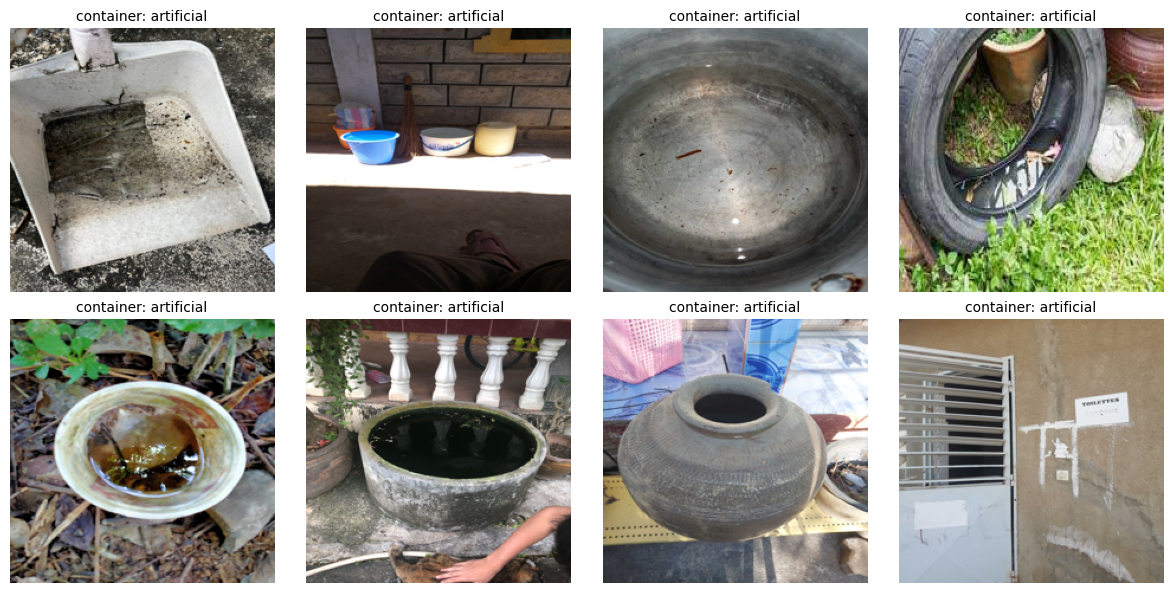

Training set: 152 images
Test set: 38 images
Train class distribution: [38 37 38 39]
Test class distribution: [ 9  9 10 10]


In [8]:
# Convert to numpy arrays
X = np.array(images)
y = np.array(labels)

# Encode labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

print(f"\nNumber of classes: {num_classes}")
print(f"Classes: {label_encoder.classes_}")
print(f"Samples per class: {np.bincount(y_encoded)}")

# Visualize Sample Images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < len(X):
        ax.imshow(X[i])
        ax.set_title(f"{y[i]}", fontsize=10)
        ax.axis('off')
plt.tight_layout()
plt.show()

# Split Data: 80% Train, 20% Test
# Stratified split ensures each class is proportionally represented

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"Training set: {len(X_train)} images")
print(f"Test set: {len(X_test)} images")
print(f"Train class distribution: {np.bincount(y_train)}")
print(f"Test class distribution: {np.bincount(y_test)}")

## Build Transfer Learning Model
**Transfer Learning**: Use a model pre-trained on millions of images, allowing us to refine the model to classify images we are particularly interested in
- **ResNet-50** has already learned to recognize edges, textures, shapes, objects
- We freeze these learned features (keep the weights)
- We only train new layers on top to classify water sources
- This works much better with small datasets!

In [9]:
# Load pre-trained ResNet-50
print("Loading pre-trained ResNet-50 from ImageNet...")
base_model = ResNet50(
    weights='imagenet',   # Pre-trained weights
    include_top=False,    # Exclude original classification layer
    input_shape=(224, 224, 3)
)

# Freeze the base model layers
base_model.trainable = False
print(f"Frozen {len(base_model.layers)} pre-trained layers")

# Build the complete model
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Loading pre-trained ResNet-50 from ImageNet...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Frozen 175 pre-trained layers


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Now, we train the model with the NASA GLOBE images.

In [ ]:
# Only the top layers train while the ResNet-50 base provides powerful features
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# Unfreeze and fine-tune base model
# After initial training, we can unfreeze some top layers of ResNet for better results
print("\nFine-tuning: Unfreezing top layers of ResNet-50...")
base_model.trainable = True

# Freeze all layers except the last 10
for layer in base_model.layers[:-10]:
    layer.trainable = False

print(f"Trainable layers: {sum([1 for layer in model.layers if layer.trainable])}")

# Recompile with lower learning rate for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training
history_fine = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

for key in history.history.keys():
    history.history[key].extend(history_fine.history[key])

In [ ]:
# Visualize training progress
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
ax1.plot(history.history['accuracy'], label='Training')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.axvline(x=20, color='gray', linestyle='--', alpha=0.5, label='Fine-tuning starts')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history['loss'], label='Training')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.axvline(x=20, color='gray', linestyle='--', alpha=0.5, label='Fine-tuning starts')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Next, we'll evaluate the model's accuracy on the test set (the 20% of the 200 images that we initially set aside). The test set performance shows how well the model generalizes to new, unseen images.


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.2%}")
print(f"Test Loss: {test_loss:.4f}")

# Get predictions
y_pred = np.argmax(model.predict(X_test), axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

Lastly, we'll visualize the model's classifications on some of the test images.

In [ ]:
# Visualize predictions on test images

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
indices = np.random.choice(len(X_test), size=min(12, len(X_test)), replace=False)

for i, ax in enumerate(axes.flat):
    if i < len(indices):
        idx = indices[i]
        ax.imshow(X_test[idx])

        # Get prediction probabilities
        pred_probs = model.predict(X_test[idx:idx+1], verbose=0)[0]
        pred_class = np.argmax(pred_probs)
        confidence = pred_probs[pred_class]

        true_label = label_encoder.inverse_transform([y_test[idx]])[0]
        pred_label = label_encoder.inverse_transform([pred_class])[0]
        color = 'green' if true_label == pred_label else 'red'

        ax.set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1%})",
                     color=color, fontsize=9)
        ax.axis('off')
plt.tight_layout()
plt.show()